In [ ]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]

Saving Khoa.jpg to Khoa.jpg


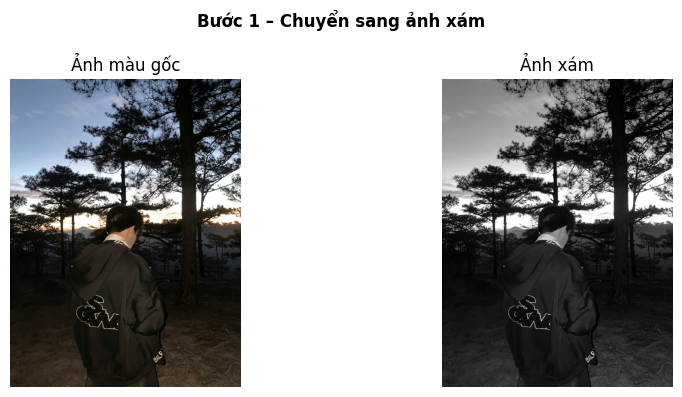

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_mau = np.array(Image.open(IMAGE_PATH).convert("RGB"))

R = img_mau[:, :, 0].astype(float)
G = img_mau[:, :, 1].astype(float)
B = img_mau[:, :, 2].astype(float)
gray = np.clip(0.299*R + 0.587*G + 0.114*B, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_mau);                    plt.title("Ảnh màu gốc");  plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(gray, cmap="gray");          plt.title("Ảnh xám");       plt.axis("off")
plt.suptitle("Bước 1 – Chuyển sang ảnh xám", fontweight="bold")
plt.tight_layout(); plt.show()

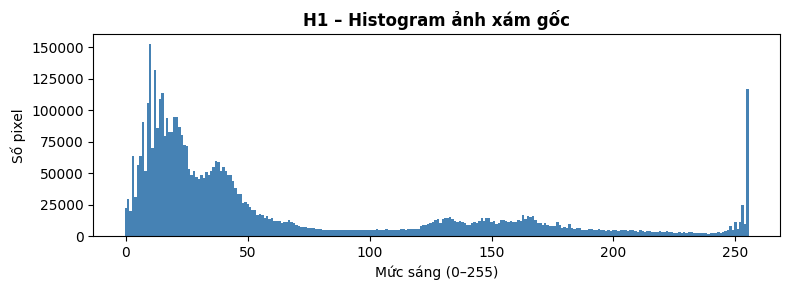

In [ ]:
H1 = np.zeros(256, dtype=int)
for gia_tri in gray.ravel():
    H1[gia_tri] += 1

plt.figure(figsize=(8, 3))
plt.bar(range(256), H1, color="steelblue", width=1)
plt.title("H1 – Histogram ảnh xám gốc", fontweight="bold")
plt.xlabel("Mức sáng (0–255)"); plt.ylabel("Số pixel")
plt.tight_layout(); plt.show()

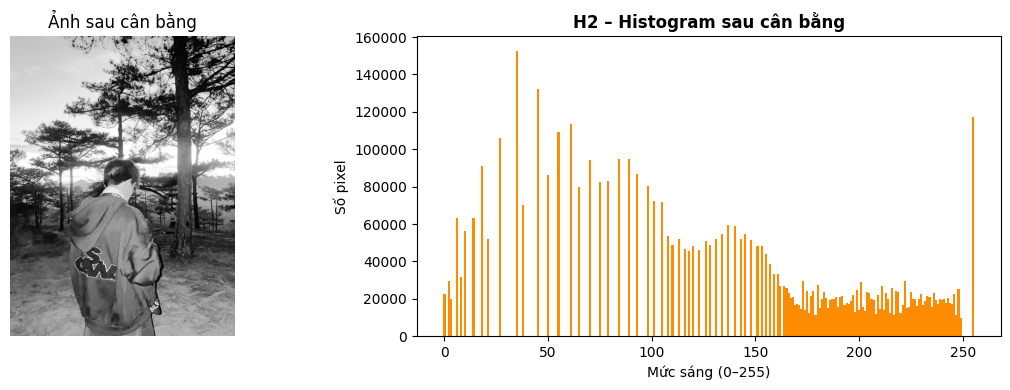

In [ ]:
N    = gray.size
cdf  = np.cumsum(H1)
cdf_min = cdf[cdf > 0][0]

lut = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)

eq_img = lut[gray]

H2 = np.zeros(256, dtype=int)
for gia_tri in eq_img.ravel():
    H2[gia_tri] += 1

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(eq_img, cmap="gray"); plt.title("Ảnh sau cân bằng"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.bar(range(256), H2, color="darkorange", width=1)
plt.title("H2 – Histogram sau cân bằng", fontweight="bold")
plt.xlabel("Mức sáng (0–255)"); plt.ylabel("Số pixel")
plt.tight_layout(); plt.show()

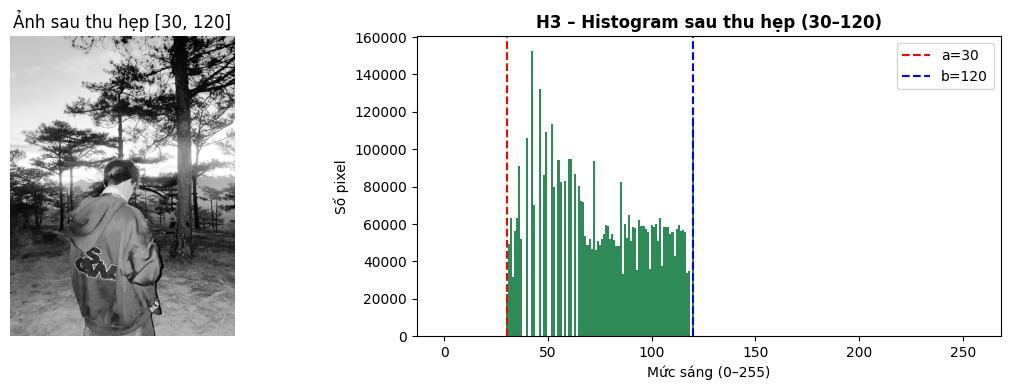

Pixel nhỏ nhất: 30, lớn nhất: 120  (phải nằm trong [30, 120])


In [ ]:
a, b = 30, 120
shrunk_img = np.clip(
    np.round(a + (b - a) / 255.0 * eq_img.astype(float)),
    a, b
).astype(np.uint8)

H3 = np.zeros(256, dtype=int)
for gia_tri in shrunk_img.ravel():
    H3[gia_tri] += 1

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(shrunk_img, cmap="gray"); plt.title("Ảnh sau thu hẹp [30, 120]"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.bar(range(256), H3, color="seagreen", width=1)
plt.axvline(30,  color="red",  linestyle="--", label="a=30")
plt.axvline(120, color="blue", linestyle="--", label="b=120")
plt.title("H3 – Histogram sau thu hẹp (30–120)", fontweight="bold")
plt.xlabel("Mức sáng (0–255)"); plt.ylabel("Số pixel")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Pixel nhỏ nhất: {shrunk_img.min()}, lớn nhất: {shrunk_img.max()}  (phải nằm trong [30, 120])")

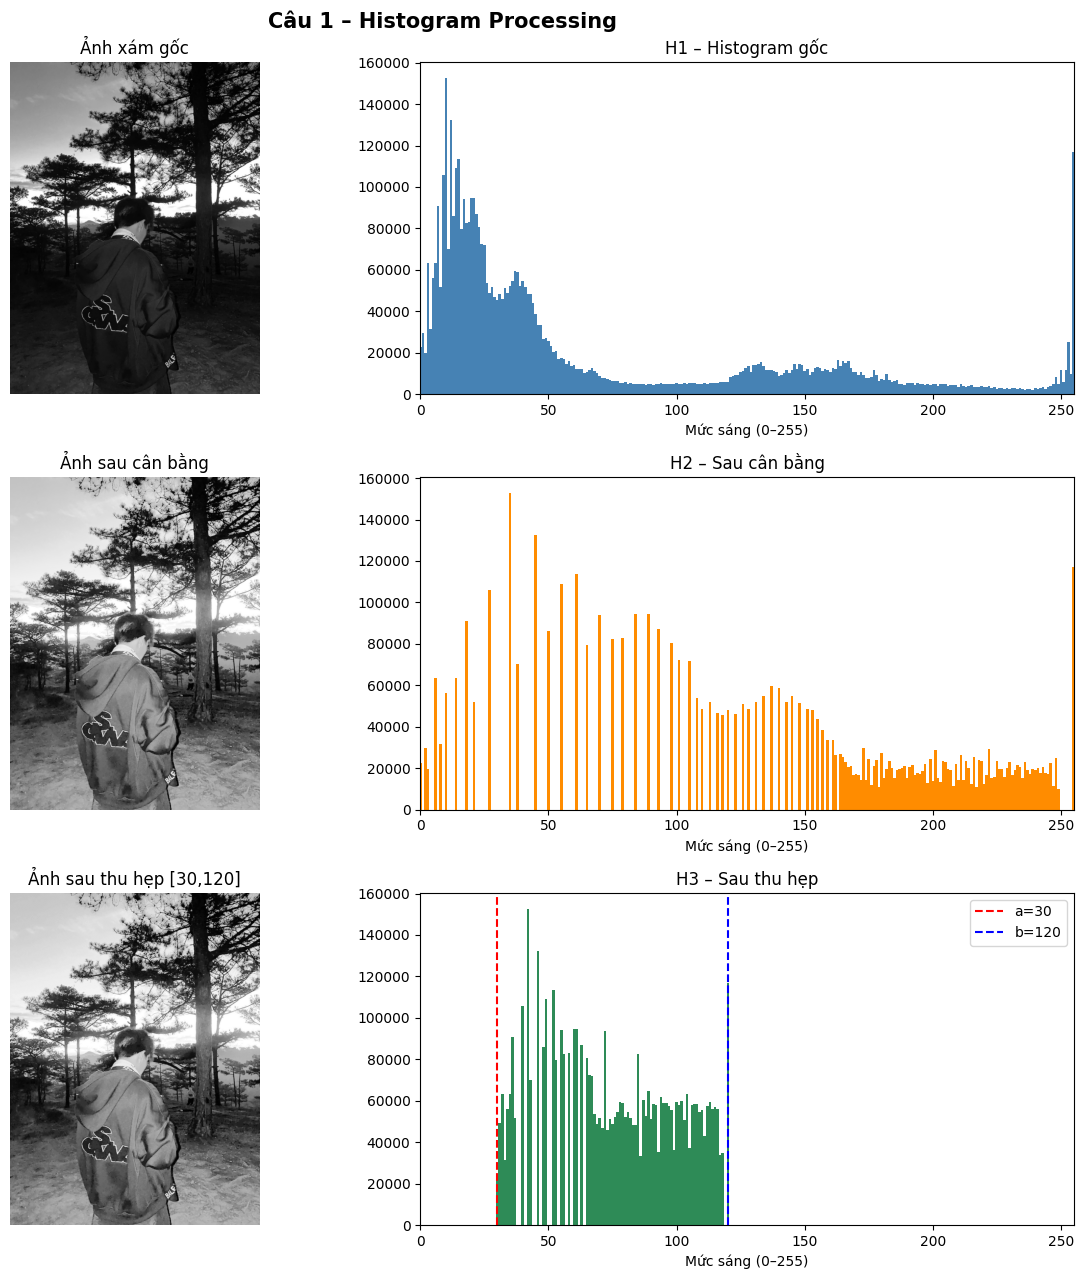

 Đã lưu: cau1_ket_qua.png


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
fig.suptitle("Câu 1 – Histogram Processing", fontsize=15, fontweight="bold")

axes[0,0].imshow(gray, cmap="gray");    axes[0,0].set_title("Ảnh xám gốc");              axes[0,0].axis("off")
axes[0,1].bar(range(256), H1, color="steelblue",  width=1); axes[0,1].set_title("H1 – Histogram gốc")

axes[1,0].imshow(eq_img, cmap="gray");  axes[1,0].set_title("Ảnh sau cân bằng");         axes[1,0].axis("off")
axes[1,1].bar(range(256), H2, color="darkorange", width=1); axes[1,1].set_title("H2 – Sau cân bằng")

axes[2,0].imshow(shrunk_img, cmap="gray"); axes[2,0].set_title("Ảnh sau thu hẹp [30,120]"); axes[2,0].axis("off")
axes[2,1].bar(range(256), H3, color="seagreen",   width=1); axes[2,1].set_title("H3 – Sau thu hẹp")
axes[2,1].axvline(30, color="red", linestyle="--", label="a=30")
axes[2,1].axvline(120, color="blue", linestyle="--", label="b=120")
axes[2,1].legend()

for ax in axes[:, 1]: ax.set_xlabel("Mức sáng (0–255)"); ax.set_xlim(0, 255)

plt.tight_layout()
plt.savefig("cau1_ket_qua.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Đã lưu: cau1_ket_qua.png")

In [ ]:
from google.colab import files
files.download("cau1_ket_qua.png")